# Air Passengers: Cleaning & EDA

World Bank air transport passenger data (1960–2023). Source: World Bank Open Data: IS.AIR.PSGR.

## 1. Setup

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [18]:
BLUE   = "#2176AE"
ORANGE = "#E76F51"
TEAL   = "#2A9D8F"
SLATE  = "#264653"
RED    = "#E63946"
GRAY   = "#C8C8C8"

plt.rcParams.update({
    "figure.dpi":          130,
    "figure.facecolor":    "white",
    "axes.facecolor":      "white",
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.grid":           False,
    "font.family":         "sans-serif",
    "axes.titlesize":      12,
    "axes.titleweight":    "bold",
    "axes.labelsize":      10,
    "xtick.labelsize":     9,
    "ytick.labelsize":     9,
    "legend.fontsize":     9,
    "legend.frameon":      False,
    "figure.titlesize":    13,
    "figure.titleweight":  "bold",
})

## 2. Data Loading & Cleaning

In [19]:
df = pd.read_csv("data/passenger.csv")
print(f"Shape: {df.shape}")
display(df.info())
display(df.sample(5))

Shape: (266, 71)
<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            146 non-null    float64
 15  1971            148 non-null    float64
 16  1972            146 non-null    float64
 17  1973            150 non-null 

None

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
15,Azerbaijan,AZE,"Air transport, passengers carried",IS.AIR.PSGR,NaN,NaN,NaN,NaN,NaN,NaN,...,2331308.0,2.279546e+06,2.585280e+06,5.452650e+05,1.102455e+06,2.171085e+06,2.581841e+06,NaN,NaN,NaN
230,East Asia & Pacific (IDA & IBRD countries),TEA,"Air transport, passengers carried",IS.AIR.PSGR,NaN,NaN,NaN,NaN,NaN,NaN,...,881640190.0,9.642707e+08,1.003418e+09,5.456042e+08,5.160831e+08,4.553563e+08,9.217183e+08,NaN,NaN,NaN
68,Euro area,EMU,"Air transport, passengers carried",IS.AIR.PSGR,NaN,NaN,NaN,NaN,NaN,NaN,...,560783691.0,5.847979e+08,6.398687e+08,1.900329e+08,2.524615e+08,5.287496e+08,6.104957e+08,NaN,NaN,NaN
14,Austria,AUT,"Air transport, passengers carried",IS.AIR.PSGR,NaN,NaN,NaN,NaN,NaN,NaN,...,16171640.0,1.293550e+07,4.647660e+07,1.328541e+07,1.890105e+07,4.009942e+07,4.604022e+07,NaN,NaN,NaN
175,Nicaragua,NIC,"Air transport, passengers carried",IS.AIR.PSGR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
empty_cols = [c for c in df.columns if df[c].isnull().all()]
print(f"Dropping {len(empty_cols)} fully-empty columns: {empty_cols}")
df = df.drop(columns=empty_cols)

before = len(df)
df = df.dropna(thresh=45)
print(f"Rows dropped (sparse): {before - len(df)}  |  Remaining: {len(df)}")

display(df.describe().round())

Dropping 13 fully-empty columns: ['1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '2024', '2025', 'Unnamed: 70']
Rows dropped (sparse): 106  |  Remaining: 160


,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
count,131.0,132.0,130.0,133.0,145.0,149.0,152.0,152.0,152.0,153.0,...,1.590000e+02,1.590000e+02,1.590000e+02,1.570000e+02,1.570000e+02,1.550000e+02,1.560000e+02,1.580000e+02,1.550000e+02,1.560000e+02
mean,14159375.0,15027282.0,14003572.0,17987523.0,19722203.0,19960760.0,21465945.0,23367779.0,26183434.0,29243827.0,...,1.612661e+08,1.738515e+08,1.864389e+08,2.035788e+08,2.184825e+08,2.298047e+08,9.544108e+07,1.167292e+08,1.621748e+08,2.195449e+08
std,52414921.0,55859963.0,53798398.0,66759616.0,66758810.0,66668404.0,71663692.0,77714297.0,87321913.0,98197125.0,...,4.364471e+08,4.687527e+08,5.003797e+08,5.396428e+08,5.763989e+08,6.020862e+08,2.507116e+08,3.129622e+08,4.324055e+08,5.742756e+08
min,17800.0,8500.0,9000.0,9500.0,10000.0,7000.0,10000.0,12000.0,12000.0,10400.0,...,0.000000e+00,6.011000e+03,6.744000e+03,1.054500e+04,1.054500e+04,7.117000e+03,3.560000e+02,5.240000e+02,3.594000e+03,3.507000e+03
25%,180400.0,216975.0,232925.0,256800.0,275700.0,250000.0,281700.0,299800.0,347650.0,402500.0,...,1.332256e+06,1.313170e+06,1.367922e+06,1.557876e+06,1.698386e+06,1.679982e+06,4.541330e+05,6.113300e+05,1.495872e+06,1.724626e+06
50%,873500.0,989850.0,1001950.0,1141600.0,1474600.0,1616500.0,1642050.0,1659400.0,1777550.0,2042900.0,...,1.099279e+07,1.147306e+07,1.268908e+07,1.367684e+07,1.336484e+07,1.612474e+07,5.134564e+06,5.483836e+06,1.215222e+07,1.560244e+07
75%,3407850.0,3822000.0,4044600.0,4623500.0,6811800.0,7320600.0,8355400.0,8761000.0,9591150.0,11291300.0,...,6.384251e+07,6.302607e+07,6.730650e+07,7.556565e+07,7.825993e+07,8.275196e+07,3.008444e+07,3.280502e+07,6.600792e+07,7.912238e+07
max,310441392.0,331604904.0,327004108.0,401571800.0,421145200.0,432276500.0,471773396.0,513269292.0,576090004.0,648400600.0,...,3.285081e+09,3.525115e+09,3.760774e+09,4.025616e+09,4.293921e+09,4.455690e+09,1.771894e+09,2.279975e+09,3.230288e+09,4.268984e+09


In [21]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
df = df.drop_duplicates()
print(f"Final shape after deduplication: {df.shape}")

Duplicate rows found: 0
Final shape after deduplication: (160, 58)


In [22]:
df.to_csv("data/clean/passenger_clean.csv", index=False)
print("Saved  →  data/clean/passenger_clean.csv")

Saved  →  data/clean/passenger_clean.csv


## 3. Exploratory Data Analysis

In [23]:
year_cols = [c for c in df.columns if str(c).isdigit()]

df_long = df.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Passengers",
)
df_long["Year"]       = df_long["Year"].astype(int)
df_long["Passengers"] = pd.to_numeric(df_long["Passengers"], errors="coerce")
df_long = df_long[df_long["Year"] <= 2023]

REGIONAL_CODES = {
    "WLD","EAS","ECS","LCN","MEA","NAC","SAS","SSF","EAP","ECA","LAC","MNA",
    "SSA","HIC","MIC","LMC","UMC","LIC","IBRD","IDA","OED","AFE","AFW","ARB",
    "CEB","CSS","EAR","EMU","EUU","FCS","HPC","IBD","IBT","IDX","IDB","INX",
    "LDC","LTE","NAF","OSS","PRE","PSS","PST","SST","TEA","TEC","TLA","TMN",
    "TSA","TSS","XZN",
}
df_countries = df_long[~df_long["Country Code"].isin(REGIONAL_CODES)].copy()
df_regions   = df_long[ df_long["Country Code"].isin(REGIONAL_CODES)].copy()
print(f"Country rows: {len(df_countries):,}  |  Regional aggregate rows: {len(df_regions):,}")

Country rows: 6,426  |  Regional aggregate rows: 2,214


### 3.1 Passenger Distribution (2019)

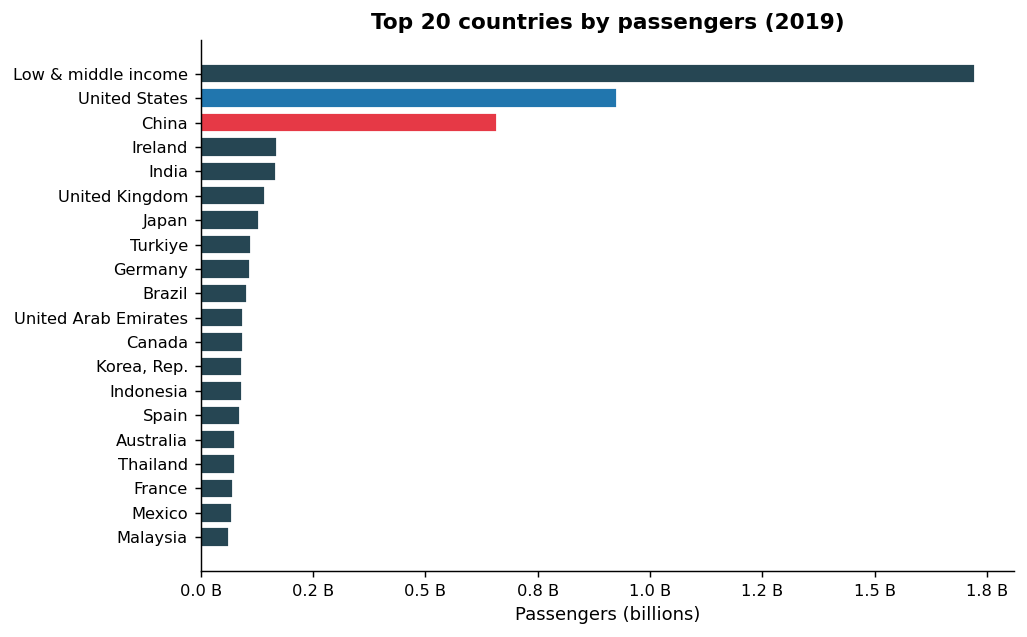

In [30]:
data_2019 = df_countries[
    (df_countries["Year"] == 2019) & df_countries["Passengers"].notna()
].copy()

top20 = data_2019.nlargest(20, "Passengers")

bar_colors = [
    RED if c == "CHN" else
    BLUE if c == "USA" else
    SLATE
    for c in top20["Country Code"]
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    top20["Country Name"],
    top20["Passengers"] / 1e9,
    color=bar_colors,
    edgecolor="white"
)

ax.set_xlabel("Passengers (billions)")
ax.set_title("Top 20 countries by passengers (2019)")

ax.invert_yaxis()

ax.xaxis.set_major_formatter(
    mticker.FormatStrFormatter("%.1f B")
)

plt.tight_layout()
plt.show()

### 3.2 Global Air Passengers Trend (1970\u20132023)

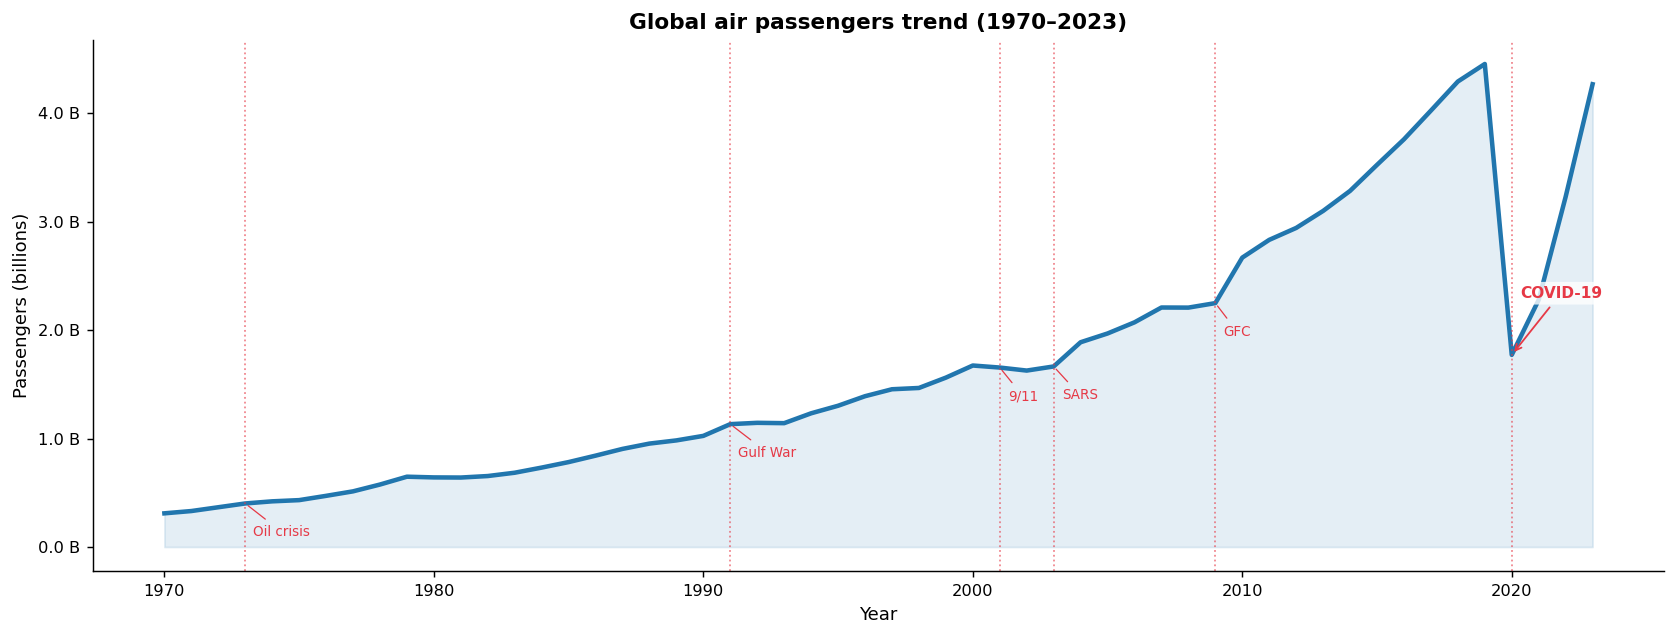

In [31]:
world_trend = df_long[df_long["Country Code"] == "WLD"].dropna(subset=["Passengers"])

if len(world_trend) < 5:
    world_trend = (
        df_countries.groupby("Year")["Passengers"]
        .sum()
        .reset_index(name="Passengers")
    )

world_trend = world_trend[world_trend["Year"] >= 1970]

events = {
    1973: ("Oil crisis", -0.3),
    1991: ("Gulf War",  -0.3),
    2001: ("9/11",      -0.3),
    2003: ("SARS",      -0.3),
    2009: ("GFC",       -0.3),
}

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(
    world_trend["Year"],
    world_trend["Passengers"] / 1e9,
    alpha=0.12,
    color=BLUE
)

ax.plot(
    world_trend["Year"],
    world_trend["Passengers"] / 1e9,
    color=BLUE,
    lw=2.5
)

# Standard event annotations
for yr, (label, offset) in events.items():
    row = world_trend[world_trend["Year"] == yr]

    if len(row):
        y = float(row["Passengers"].values[0]) / 1e9

        ax.axvline(
            yr,
            color=RED,
            ls=":",
            lw=1,
            alpha=0.6
        )

        ax.annotate(
            label,
            xy=(yr, y),
            xytext=(yr + 0.3, y + offset),
            fontsize=7.5,
            color=RED,
            arrowprops=dict(
                arrowstyle="-",
                color=RED,
                lw=0.7
            )
        )

# Improved COVID annotation
covid_year = 2020
covid_row = world_trend[world_trend["Year"] == covid_year]

if len(covid_row):
    covid_y = float(covid_row["Passengers"].values[0]) / 1e9

    ax.axvline(
        covid_year,
        color=RED,
        ls=":",
        lw=1,
        alpha=0.6
    )

    ax.annotate(
        "COVID-19",
        xy=(covid_year, covid_y),
        xytext=(2020.3, covid_y + 0.5),
        fontsize=8.5,
        color=RED,
        fontweight="bold",
        ha="left",
        va="bottom",
        arrowprops=dict(
            arrowstyle="->",
            color=RED,
            lw=1
        ),
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="none",
            alpha=0.8
        )
    )

ax.set_title("Global air passengers trend (1970–2023)")
ax.set_xlabel("Year")
ax.set_ylabel("Passengers (billions)")

ax.yaxis.set_major_formatter(
    mticker.FormatStrFormatter("%.1f B")
)

plt.tight_layout()
plt.show()